# WiniCari 05 — Détection d'Anomalies

**Module 3 : classer les trajets comme normaux ou anormaux — détecter les pannes, incidents et trajets atypiques.**

Il n'y a pas d'étiquettes d'incident dans les données. On utilise deux modèles non supervisés qui apprennent à quoi ressemble un trajet normal et signalent les écarts :

| modèle | entrée | ce qu'il détecte |
|---|---|---|
| **Isolation Forest** | vecteur de caractéristiques par trajet (immobilisation, taux de correspondance, durée...) | trajets globalement inhabituels |
| **Autoencodeur LSTM** | séquence par arrêt (immobilisation, distance d'accrochage, correspondance) | *où* dans le trajet l'anomalie s'est produite |

Signal clé : **`dwell_s`** — combien de temps le bus est resté à chaque arrêt. Un bus qui s'immobilise normalement 30 s mais reste 20 min est presque certainement en panne ou bloqué.

In [ ]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


from src.data import anomaly as an
from src.data import foundation as fdn

FOUNDATION = Path(an.__file__).resolve().parents[2] / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
fa = pd.read_parquet(FOUNDATION)
fa['trip_start'] = pd.to_datetime(fa['trip_start'])
fa['arrival']    = pd.to_datetime(fa['arrival'])
fa['departure']  = pd.to_datetime(fa['departure'])

CFG = an.AnomalyConfig()
print(f'foundation: {len(fa):,} rows | {fa["trip_id"].nunique()} trips | '
      f'dwell_s available: {fa["dwell_s"].notna().sum():,} stops')

foundation: 198,430 rows | 26132 trips | dwell_s available: 158,932 stops


## 1. Distribution du temps d'immobilisation — le signal d'anomalie central

La plupart des arrêts ont un temps d'immobilisation court (le bus ralentit pour faire monter/descendre les passagers et repart). Les longues immobilisations ressortent comme incidents : panne, embouteillage, pause conducteur, ou stationnement en terminus prévu.

C:\Users\deadx\AppData\Local\Temp\ipykernel_19836\1457017672.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax[1].boxplot([v for v in companies], vert=False,


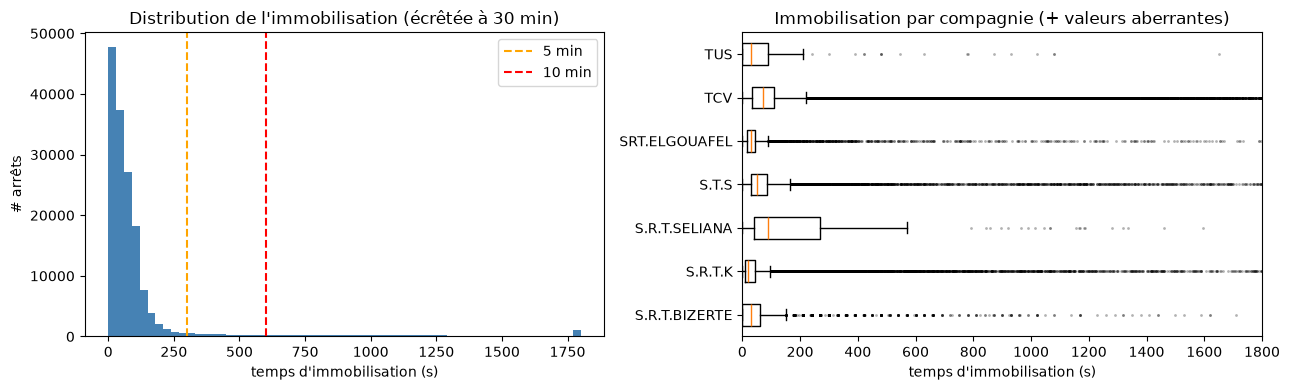

Arrêts avec immobilisation > 5 min : 12,132
Arrêts avec immobilisation > 30 min : 949


In [2]:
matched = fa[fa['matched'] & fa['dwell_s'].notna()]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(matched['dwell_s'].clip(0, 1800), bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(300, color='orange', ls='--', label='5 min')
ax[0].axvline(600, color='red',    ls='--', label='10 min')
ax[0].set_xlabel('temps d\'immobilisation (s)'); ax[0].set_ylabel('# arrêts')
ax[0].set_title('Distribution de l\'immobilisation (écrêtée à 30 min)')
ax[0].legend()

companies = matched.groupby('societe')['dwell_s'].apply(list)
bp = ax[1].boxplot([v for v in companies], vert=False,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax[1].set_yticks(range(1, len(companies) + 1))
ax[1].set_yticklabels(companies.index)
ax[1].set_xlabel('temps d\'immobilisation (s)'); ax[1].set_title('Immobilisation par compagnie (+ valeurs aberrantes)')
ax[1].set_xlim(0, 1800)
plt.tight_layout(); plt.show()

print(f'Arrêts avec immobilisation > 5 min : {(matched["dwell_s"]>300).sum():,}')
print(f'Arrêts avec immobilisation > 30 min : {(matched["dwell_s"]>1800).sum():,}')

## 2. Matrice de caractéristiques des trajets

On réduit chaque trajet à un vecteur de caractéristiques de longueur fixe :

| caractéristique | ce qu'elle capte |
|---|---|
| `max_dwell_s` | pire immobilisation du trajet — le signal de panne le plus fort |
| `mean_dwell_s` | immobilisation moyenne — rythme général |
| `n_stops` | arrêts correspondants (faible = problème GPS ou qualité de route) |
| `match_rate` | fraction d'arrêts atteints (faible = bus a dévié ou a fait demi-tour tôt) |
| `total_elapsed` | durée totale du trajet en minutes |
| `dist_m_max` | pire distance d'accrochage à un arrêt (élevé = bus a quitté l'itinéraire) |

In [3]:
trips = an.trip_features(fa, CFG)
print(f'trips: {len(trips):,} | lines: {trips["line"].nunique()} | '
      f'companies: {trips["societe"].nunique()}')
display(trips[an.FEATURES].describe().round(1))

trips: 26,132 | lines: 60 | companies: 7


,n_stops,match_rate,max_dwell_s,mean_dwell_s,total_elapsed,dist_m_max,max_dark_s,elapsed_vs_bus_z,elapsed_vs_line_z
count,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0,26132.0
mean,6.1,0.9,517.7,136.2,64.9,98.2,99.6,-0.0,-0.0
std,4.2,0.2,644.6,120.3,93.5,83.6,992.5,1.0,1.0
min,3.0,0.1,0.0,0.0,3.4,2.0,0.0,-4.3,-4.8
25%,4.0,0.8,115.0,54.6,20.3,29.0,0.0,-0.6,-0.5
50%,5.0,0.8,195.1,81.0,30.0,48.0,0.0,-0.0,-0.1
75%,6.0,1.0,800.0,203.2,44.8,170.0,0.0,0.4,0.3
max,31.0,1.0,9891.9,2462.5,989.4,349.0,55997.9,21.9,28.5


## 3. Isolation Forest — score d'anomalie au niveau trajet

L'Isolation Forest évalue la facilité avec laquelle un trajet peut être isolé du reste. Les trajets anormaux (immobilisation inhabituelle, faible taux de correspondance, etc.) sont isolés avec moins de divisions → score d'anomalie plus élevé.

trajets anormaux signalés : 3520 / 26132 (13.5%)


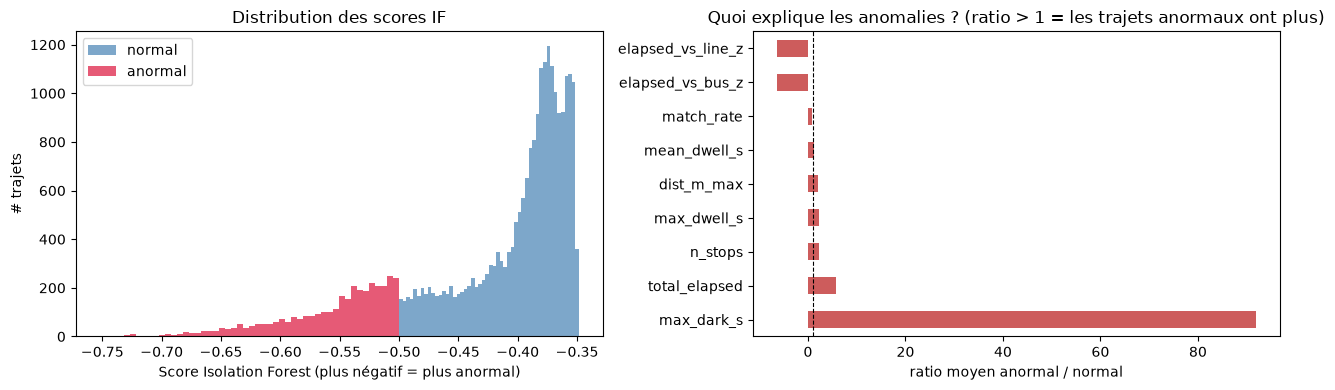

In [4]:
if_model, if_mean, if_std = an.train_isolation_forest(trips, CFG)
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)

n_anom = trips_scored['anomaly'].sum()
print(f'trajets anormaux signalés : {n_anom} / {len(trips_scored)} '
      f'({100*n_anom/len(trips_scored):.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(trips_scored.loc[~trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='steelblue', label='normal')
ax[0].hist(trips_scored.loc[trips_scored['anomaly'],  'if_score'],
           bins=50, alpha=0.7, color='crimson', label='anormal')
ax[0].set_xlabel('Score Isolation Forest (plus négatif = plus anormal)')
ax[0].set_ylabel('# trajets'); ax[0].set_title('Distribution des scores IF')
ax[0].legend()

feat_means = trips_scored.groupby('anomaly')[an.FEATURES].mean().T
feat_means.columns = ['normal', 'anormal']
ratio = (feat_means['anormal'] / feat_means['normal']).sort_values(ascending=False)
ratio.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].axvline(1, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('ratio moyen anormal / normal')
ax[1].set_title('Quoi explique les anomalies ? (ratio > 1 = les trajets anormaux ont plus)')
plt.tight_layout(); plt.show()

In [5]:
# Top anomalous trips
top_anom = (trips_scored[trips_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['day','line','societe','dir','n_stops','match_rate',
                        'max_dwell_s','total_elapsed','if_score']])
top_anom['match_rate'] = top_anom['match_rate'].round(2)
top_anom['max_dwell_s'] = top_anom['max_dwell_s'].round(0).astype(int)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 most anomalous trips:')
display(top_anom)

Top 15 most anomalous trips:


,day,line,societe,dir,n_stops,match_rate,max_dwell_s,total_elapsed,if_score
3999,20250227,3,TCV,RETOUR,4,0.33,2530,83.586250,-0.752
2730,20250213,4,TCV,RETOUR,5,1.00,1215,276.239500,-0.740
1670,20250203,4,TCV,RETOUR,4,0.80,130,387.742383,-0.732
222,20220824,410,S.R.T.BIZERTE,RETOUR,7,0.78,1170,409.922917,-0.731
19076,20251215,3,TCV,ALLER,7,0.78,100,237.797400,-0.731
740,20230120,410,S.R.T.BIZERTE,RETOUR,8,0.89,810,412.093333,-0.731
16676,20251022,4,TCV,RETOUR,5,1.00,215,261.567550,-0.729
21479,20260131,3,TCV,ALLER,3,0.50,80,185.999017,-0.729
758,20230125,403,S.R.T.BIZERTE,RETOUR,6,1.00,210,396.206817,-0.728
618,20221223,403,S.R.T.BIZERTE,RETOUR,6,1.00,960,395.275750,-0.727


## 4. Autoencodeur LSTM — anomalie au niveau séquence

Le LSTM apprend à quoi ressemble une **progression arrêt par arrêt** normale : comment l'immobilisation croît et décroît, comment le bus s'accroche aux arrêts, quels arrêts sont correspondants. Un trajet avec une **erreur de reconstruction** élevée a un schéma d'arrêts que le modèle n'a jamais vu à l'entraînement — c'est là que quelque chose a mal tourné.

In [6]:
X, trip_ids = an.build_sequences(fa, CFG)
print(f'sequence tensor: {X.shape}  (trips x stops x features)')
print(f'features: {an.SEQ_FEATURES}')

sequence tensor: (26132, 30, 3)  (trips x stops x features)
features: ['dwell_s', 'dist_m', 'matched']


  époque 10/30  perte=0.01067
  époque 20/30  perte=0.00884
  époque 30/30  perte=0.00763
Seuil LSTM (95e percentile) : 0.05065
Trajets anormaux LSTM : 1307 / 26132 (5.0%)

Accord IF vs LSTM : 89.6%
Signalés par LES DEUX modèles : 1059 trajets (anomalies à plus haute confiance)


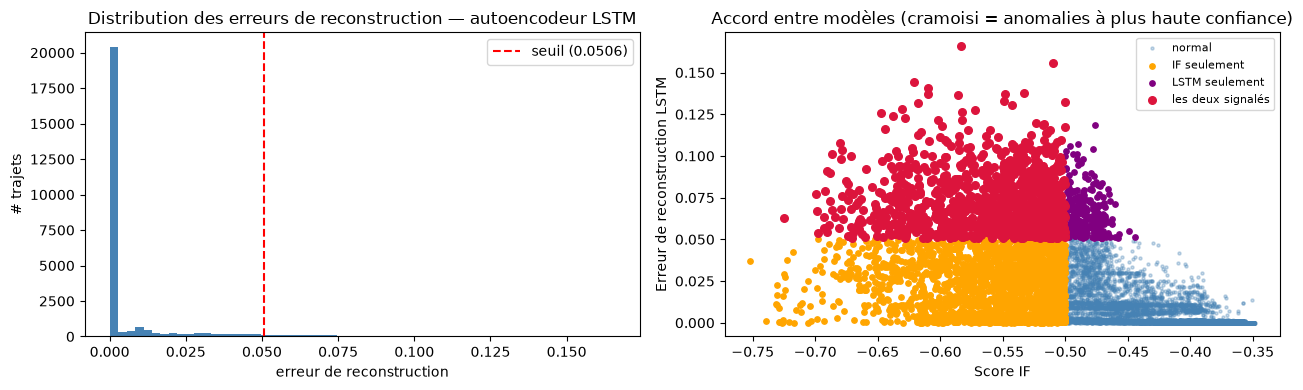

In [7]:
lstm_model, train_errors = an.train_lstm_autoencoder(X, CFG)

threshold = float(np.percentile(train_errors, 95))
lstm_anom = train_errors > threshold
print(f'Seuil LSTM (95e percentile) : {threshold:.5f}')
print(f'Trajets anormaux LSTM : {lstm_anom.sum()} / {len(train_errors)} '
      f'({100*lstm_anom.mean():.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(train_errors, bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(threshold, color='red', ls='--', label=f'seuil ({threshold:.4f})')
ax[0].set_xlabel('erreur de reconstruction'); ax[0].set_ylabel('# trajets')
ax[0].set_title('Distribution des erreurs de reconstruction — autoencodeur LSTM')
ax[0].legend()

id_cols = list(an.TRIP_KEYS)
id_df = pd.DataFrame(trip_ids, columns=id_cols)
id_df['lstm_anom'] = lstm_anom
id_df['lstm_err'] = train_errors
merged = trips_scored.merge(id_df, on=id_cols, how='inner')
agree = ((merged['anomaly'] == merged['lstm_anom'])).mean()
print(f'\nAccord IF vs LSTM : {100*agree:.1f}%')
both = ((merged['anomaly']) & (merged['lstm_anom'])).sum()
print(f'Signalés par LES DEUX modèles : {both} trajets (anomalies à plus haute confiance)')

ax[1].scatter(merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=5, alpha=0.3, color='steelblue', label='normal')
ax[1].scatter(merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=15, color='orange', label='IF seulement')
ax[1].scatter(merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=15, color='purple', label='LSTM seulement')
ax[1].scatter(merged.loc[merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=30, color='crimson', zorder=5, label='les deux signalés')
ax[1].set_xlabel('Score IF'); ax[1].set_ylabel('Erreur de reconstruction LSTM')
ax[1].set_title('Accord entre modèles (cramoisi = anomalies à plus haute confiance)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Analyse approfondie : inspection du trajet le plus anormal

Examen du profil d'immobilisation arrêt par arrêt du trajet ayant la plus grande erreur de reconstruction.

Trajet le plus anormal (LSTM) :
{'day': '20260322', 'line': '217', 'societe': 'S.R.T.K', 'bus': '6030', 'trip_id': np.int64(22006)}


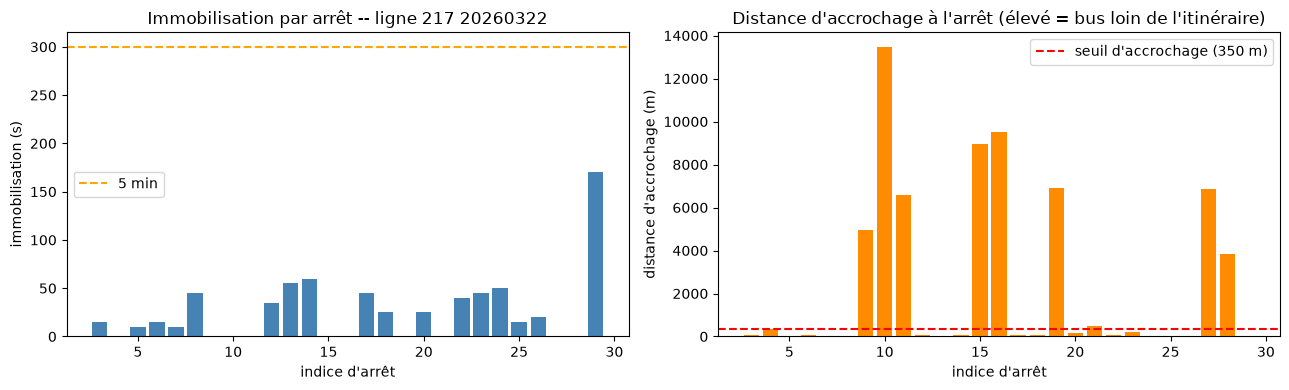

,seq,stop,arrival,departure,dwell_s,dist_m,matched
164449,3,CHRAYA,15:13:01,15:13:16,15.0,68.0,True
164450,4,SBEITLA,NaN,NaN,NaN,351.0,False
164451,5,M'GHILLA,14:34:31,14:34:41,10.0,45.0,True
164452,6,BLAKATJELMA,14:28:11,14:28:26,15.0,55.0,True
164453,7,CHASTEL,14:19:01,14:19:11,10.0,19.0,True
164454,8,EL HAJEB,14:14:45,14:15:30,45.0,44.0,True
164455,9,RHIMA,NaN,NaN,NaN,4965.0,False
164456,10,EL FOUNDEK,NaN,NaN,NaN,13476.0,False
164457,11,EL HOUAREB,NaN,NaN,NaN,6582.0,False
164458,12,BLAKHAFFOUZ,13:30:40,13:31:15,35.0,59.0,True


In [8]:
worst_idx = int(np.argmax(train_errors))
worst_keys = dict(zip(an.TRIP_KEYS, trip_ids[worst_idx]))
print('Trajet le plus anormal (LSTM) :'); print(worst_keys)

trip_rows = fa[
    (fa['day'] == worst_keys['day']) &
    (fa['line'] == worst_keys['line']) &
    (fa['societe'] == worst_keys['societe']) &
    (fa['bus'] == worst_keys['bus']) &
    (fa['trip_id'] == worst_keys['trip_id'])
].sort_values('seq')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(trip_rows['seq'], trip_rows['dwell_s'].fillna(0),
          color=['crimson' if d > 300 else 'steelblue'
                 for d in trip_rows['dwell_s'].fillna(0)])
ax[0].axhline(300, color='orange', ls='--', label='5 min')
ax[0].set_xlabel('indice d\'arrêt'); ax[0].set_ylabel('immobilisation (s)')
ax[0].set_title(f'Immobilisation par arrêt -- ligne {worst_keys["line"]} {worst_keys["day"]}')
ax[0].legend()

ax[1].bar(trip_rows['seq'], trip_rows['dist_m'].fillna(0), color='darkorange')
ax[1].axhline(350, color='red', ls='--', label='seuil d\'accrochage (350 m)')
ax[1].set_xlabel('indice d\'arrêt'); ax[1].set_ylabel('distance d\'accrochage (m)')
ax[1].set_title('Distance d\'accrochage à l\'arrêt (élevé = bus loin de l\'itinéraire)')
ax[1].legend()
plt.tight_layout(); plt.show()

display(trip_rows[['seq','stop','arrival','departure','dwell_s','dist_m','matched']]
        .assign(arrival=lambda d: d['arrival'].dt.strftime('%H:%M:%S'),
                departure=lambda d: d['departure'].dt.strftime('%H:%M:%S')))

## 6. Détection d'anomalies — ventes de tickets (signal complémentaire)

Les modules 1-5 ci-dessus scorent chaque **trajet** GPS. Ce module ajoute un signal
**complémentaire, pas fusionné** : les ventes de tickets sont agrégées par
(société, ligne, bus, **jour**) dans `tickets_daily` -- un bus peut faire plusieurs
trajets par jour, donc répartir un total journalier de tickets entre trajets individuels
demanderait une hypothèse inventée. On reste donc au grain jour : *ce bus a-t-il vendu un
nombre de tickets / une recette anormale ce jour-là sur cette ligne, comparé à sa propre
normale ?*

Mêmes principes que les modules GPS : un Isolation Forest **par société** (`contamination=
'auto'`, data-driven), pas de seuil forcé. Paramètres modifiables dans `TICKET_CFG`
ci-dessous.

In [9]:
from src.data import reference_db as rdb
from src.data import ticket_anomaly as ta
from src.models import ticket_anomaly as ta_model

conn = rdb.init_db()

TICKET_CFG = ta.TicketAnomalyConfig(
    if_contamination='auto',   # 'auto' = seuil naturel IF, ou un float ex. 0.05 pour forcer
    if_n_estimators=200,
    min_records_per_company=30,
)

tickets_df = ta.build_features(ta.load_tickets_daily(conn))
print(f"jours billetterie : {len(tickets_df):,} | sociétés : {tickets_df['societe'].nunique()} | "
      f"lignes : {tickets_df['line'].nunique()}")
display(tickets_df[ta.FEATURES].describe().round(2))

jours billetterie : 7,069 | sociétés : 5 | lignes : 89


,nbr_ticket,recette,avg_fare
count,7069.00,7069.00,7069.00
mean,132.95,367.64,4.12
std,146.97,311.83,4.03
min,1.00,0.00,0.00
25%,55.00,149.60,1.70
50%,95.00,287.30,1.70
75%,150.00,504.85,5.74
max,1571.00,3724.56,33.07


**Ce que montre ce tableau :** Statistiques des 3 caractéristiques par jour-bus-ligne :
`nbr_ticket` (volume), `recette` (DT), `avg_fare` (recette/ticket -- un prix moyen aberrant
signale une erreur de caisse ou une fraude, indépendamment du volume).

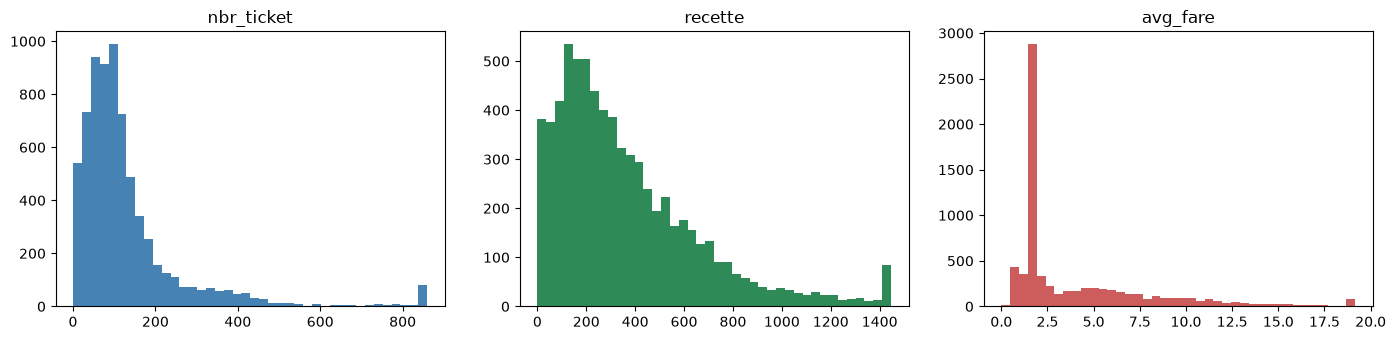

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
for a, col, color in zip(ax, ta.FEATURES, ['steelblue','seagreen','indianred']):
    a.hist(tickets_df[col].clip(upper=tickets_df[col].quantile(0.99)), bins=40, color=color)
    a.set_title(col)
plt.tight_layout(); plt.show()

### Isolation Forest par société — ventes de tickets

  jours billetterie : 7,069
    S.R.T.K: 417/2162 signalés (19.3%)
    S.R.T.SELIANA: 150/862 signalés (17.4%)
    S.T.S: 170/941 signalés (18.1%)
    SRT.ELGOUAFEL: 96/445 signalés (21.6%)
    TCV: 636/2659 signalés (23.9%)
    total signalés : 1469/7069 (20.8%)
  -> Artefacts sauvegardés dans models\ticket_anomaly


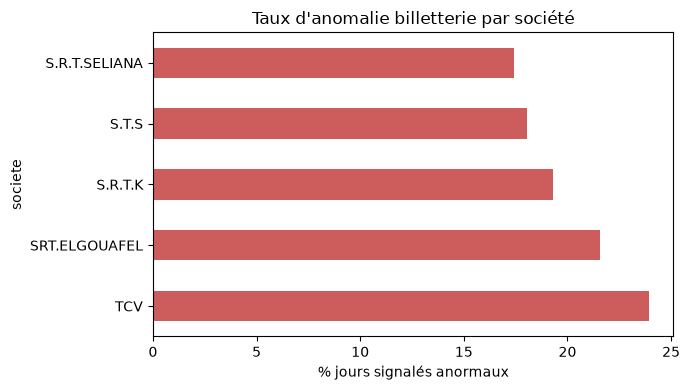

In [11]:
result = ta_model.train(conn)
days_scored = result['days']

fig, ax = plt.subplots(figsize=(7,4))
rates = days_scored.groupby('societe')['anomaly'].mean().sort_values(ascending=False) * 100
rates.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% jours signalés anormaux'); ax.set_title("Taux d'anomalie billetterie par société")
plt.tight_layout(); plt.show()

**Interprétation :** chaque société a son propre modèle -- un jour normal pour TCV
(ligne urbaine à haute fréquence, gros volumes) n'est pas comparé à la normale de
S.R.T.SELIANA (ligne régionale, petits volumes). Le taux d'anomalie par société reflète sa
propre variance interne, pas une comparaison brute entre sociétés de tailles différentes.

In [12]:
top_anom = (days_scored[days_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['societe','line','bus','day','nbr_ticket','recette','avg_fare','if_score']])
top_anom['avg_fare'] = top_anom['avg_fare'].round(2)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 jours-bus les plus anormaux (ventes de tickets) :')
display(top_anom)

Top 15 jours-bus les plus anormaux (ventes de tickets) :


,societe,line,bus,day,nbr_ticket,recette,avg_fare,if_score
4590,TCV,4,157,20250227,544,924.80,1.70,-0.813
5050,TCV,4,176,20250519,546,928.20,1.70,-0.813
4599,TCV,4,157,20250228,528,897.60,1.70,-0.809
4516,TCV,4,157,20250217,500,850.00,1.70,-0.795
4497,TCV,4,157,20250214,477,810.90,1.70,-0.786
4413,TCV,4,157,20250203,475,807.50,1.70,-0.784
5268,TCV,4,157,20250630,462,785.40,1.70,-0.778
4583,TCV,4,157,20250226,457,776.90,1.70,-0.774
4484,TCV,4,157,20250212,456,775.20,1.70,-0.773
4600,TCV,4,173,20250228,442,751.40,1.70,-0.758


## Save to production artifact (GPS anomaly module)

Sections above trained inline via `src.data.anomaly` directly, for exploration. This final
cell calls the exact same `src.models.anomaly.train()` function `src/train_pipeline.py`
calls, saving to the same `models/anomaly/` location (per-company Isolation Forest +
per-company LSTM autoencoder, with global fallback) — so running this notebook end-to-end
is a complete, equivalent alternative to running the pipeline command, not just a demo.


In [13]:
from src.models import anomaly as anomaly_model

ROOT = Path(an.__file__).resolve().parents[2]
FOUNDATION_PATH = ROOT / "data" / "processed" / "foundation_arrivals_full.parquet"
SAVE_DIR = ROOT / "models" / "anomaly"

result = anomaly_model.train(FOUNDATION_PATH, SAVE_DIR)
print(f"n_if: {result['n_if']} n_lstm: {result['n_lstm']}")
print(f"-> Artifacts saved to {SAVE_DIR.resolve()}")


  Chargement de la fondation...
  Entraînement des Isolation Forests (un par opérateur)...
    trajets total : 26,132
    S.R.T.BIZERTE: 90/961 signalés (9.4%)
    S.R.T.K: 324/2614 signalés (12.4%)
    S.R.T.SELIANA: 18/106 signalés (17.0%)
    S.T.S: 271/2258 signalés (12.0%)
    SRT.ELGOUAFEL: 73/660 signalés (11.1%)
    TCV: 2019/19496 signalés (10.4%)
    TUS: 8/37 signalés (21.6%)
    total signalés : 2803/26132 (10.7%)
  Entraînement des Autoencodeurs LSTM (par société, repli global si trop peu de données)...
  époque 10/30  perte=0.02510
  époque 20/30  perte=0.02478
  époque 30/30  perte=0.02431
    S.R.T.BIZERTE: 48/961 signalés (seuil=0.04754)
  époque 10/30  perte=0.06805
  époque 20/30  perte=0.06029
  époque 30/30  perte=0.05704
    S.R.T.K: 131/2614 signalés (seuil=0.10715)
    S.R.T.SELIANA: 106 trajets -- trop peu pour un LSTM dédié, repli global
  époque 10/30  perte=0.03472
  époque 20/30  perte=0.03105
  époque 30/30  perte=0.02777
    S.T.S: 113/2258 signalés (seui